# Exploratory Data Analysis (EDA) of MRI Brain Tumor Dataset

This notebook performs exploratory data analysis on the brain tumor dataset.

In [1]:

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")


In [2]:

dataset_dir = r"d:\Brain tumor project\DATA\dataset\balanced_dataset"
train_dir = os.path.join(dataset_dir, "Training")
val_dir = os.path.join(dataset_dir, "Validation")
test_dir = os.path.join(dataset_dir, "Testing")

classes = ['glioma', 'meningioma', 'notumor', 'pituitary']
print(f"Classes: {classes}")


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


            Training  Validation  Testing  Total
glioma          2324         498      499   3321
meningioma      2324         498      499   3321
notumor         2324         498      499   3321
pituitary       2324         498      499   3321


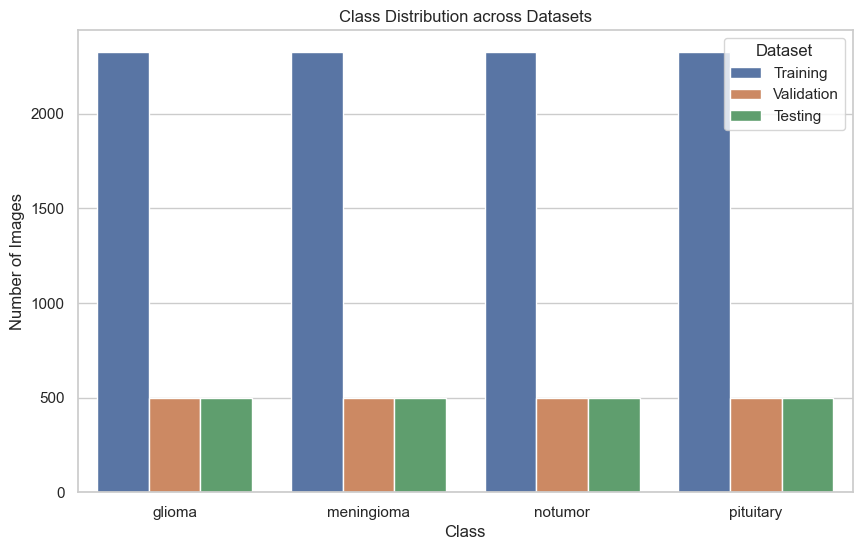

In [3]:

def get_class_counts(directory):
    counts = {}
    if os.path.exists(directory):
        for cls in classes:
            cls_path = os.path.join(directory, cls)
            if os.path.exists(cls_path):
                counts[cls] = len(os.listdir(cls_path))
            else:
                counts[cls] = 0
    return counts

train_counts = get_class_counts(train_dir)
val_counts = get_class_counts(val_dir)
test_counts = get_class_counts(test_dir)

df_counts = pd.DataFrame({
    'Training': train_counts,
    'Validation': val_counts,
    'Testing': test_counts
})

df_counts['Total'] = df_counts.sum(axis=1)
print(df_counts)

# Plotting the distributions
df_counts_melt = df_counts.drop(columns='Total').reset_index().melt(id_vars='index', var_name='Dataset', value_name='Count')
df_counts_melt.rename(columns={'index': 'Class'}, inplace=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_counts_melt, x='Class', y='Count', hue='Dataset')
plt.title('Class Distribution across Datasets')
plt.ylabel('Number of Images')
plt.show()


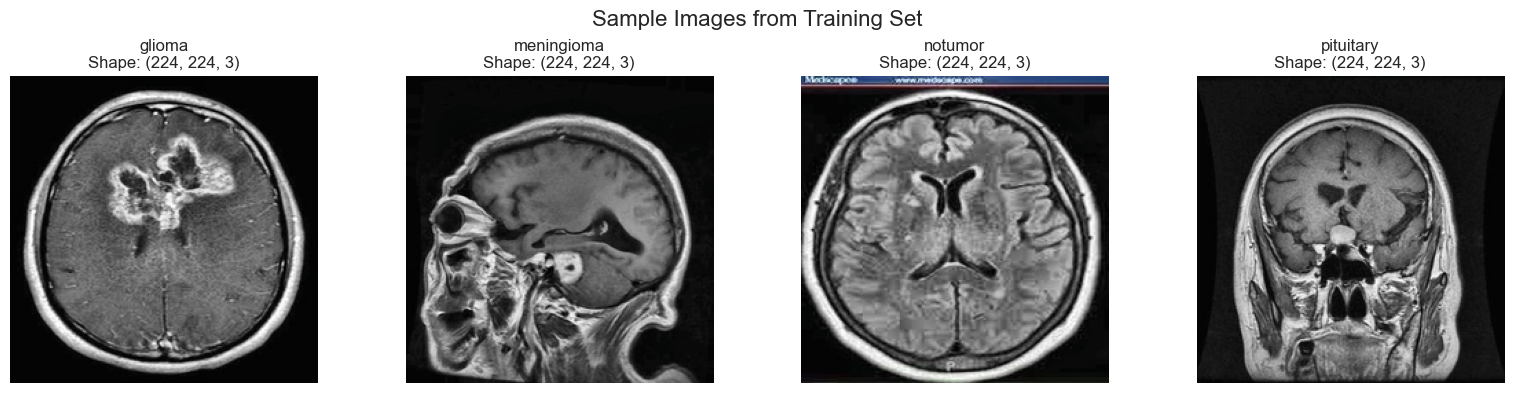

In [4]:

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)
    if os.path.exists(cls_path):
        images = os.listdir(cls_path)
        if images:
            img_path = os.path.join(cls_path, images[0])
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i].imshow(img)
            axes[i].set_title(f"{cls}\nShape: {img.shape}")
            axes[i].axis('off')
plt.suptitle('Sample Images from Training Set', fontsize=16)
plt.tight_layout()
plt.show()


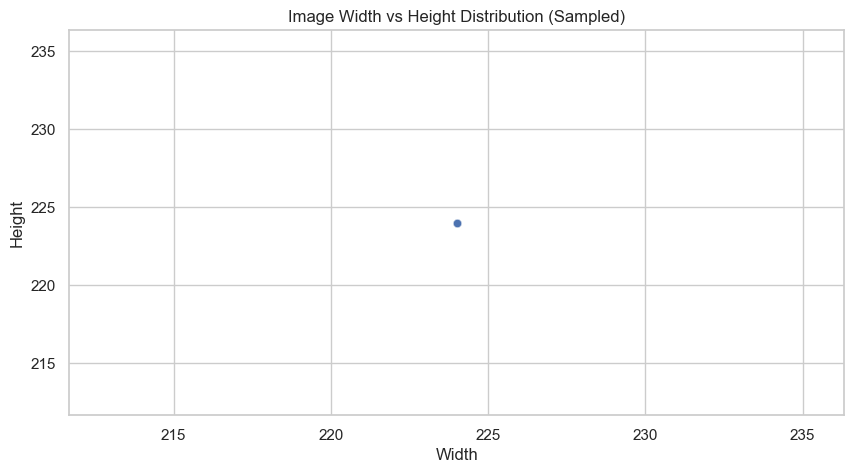

Average width: 224.00, Average height: 224.00
Min width: 224, Min height: 224
Max width: 224, Max height: 224


In [5]:

# Let's check a sample of image sizes to understand dimension distribution
import random

widths = []
heights = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    if os.path.exists(cls_path):
        images = os.listdir(cls_path)
        # Sample at most 100 images per class for speed
        sampled_images = random.sample(images, min(100, len(images)))
        for img_name in sampled_images:
            img_path = os.path.join(cls_path, img_name)
            try:
                with Image.open(img_path) as img:
                    w, h = img.size
                    widths.append(w)
                    heights.append(h)
            except:
                pass

plt.figure(figsize=(10, 5))
sns.scatterplot(x=widths, y=heights, alpha=0.5)
plt.title('Image Width vs Height Distribution (Sampled)')
plt.xlabel('Width')
plt.ylabel('Height')
plt.show()

print(f"Average width: {np.mean(widths):.2f}, Average height: {np.mean(heights):.2f}")
print(f"Min width: {np.min(widths)}, Min height: {np.min(heights)}")
print(f"Max width: {np.max(widths)}, Max height: {np.max(heights)}")
